# 03 - PhysioNet Challenge sources: Georgia, CPSC 2018, CPSC-Extra and Chapman/Shaoxing

These four collections were released through the PhysioNet/CinC Challenges 2020 and 2021:

- **Georgia** (G12EC): about 10,000 ECGs from Emory University, Atlanta, USA;
- **CPSC 2018** and **CPSC-Extra**: about 10,000 ECGs from the China Physiological Signal Challenge,
  from the same group of Chinese hospitals;
- **Chapman/Shaoxing**: about 10,000 ECGs from Shaoxing People's Hospital, China.

All four share one format: WFDB headers carrying age, sex and SNOMED-CT diagnosis codes, and signals in
`.mat` files. This notebook describes them side by side: format, missing and wrong values, demographics,
diagnoses and how they relate to age and sex, duplicates, and signal quality. Everything is read from the
raw files in `data/raw/challenge-2020/1.0.2/` and `data/raw/challenge-2021/1.0.3/`.

In [1]:
import sys
from pathlib import Path

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from eda.challenge import challenge_summary, load_headers, read_signal, signal_hashes, snomed_names
from eda.cross import CONDITIONS, condition_flags
from eda.ptbxl import load_metadata
from eda.ptbxl_signals import ptbxl_summary
from eda.signals import plot_ecg, problem_counts
from eda.stats import age_band, odds_ratios, plot_prevalence, prevalence

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 3)
sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")
plt.rcParams.update({"figure.dpi": 100})

headers = load_headers()
SOURCES = ["georgia", "cpsc_2018", "cpsc_2018_extra", "chapman_shaoxing"]

## 1. Format and size

,records,sampling_rates,units,gain,lead_orders
source,,,,,
georgia,10344,[500],[mV],[1000.0],1
cpsc_2018,6877,[500],[mV],[1000.0],1
cpsc_2018_extra,3453,[500],[mV],[1000.0],1
chapman_shaoxing,10247,[500],[mV],[1000.0],1


,count,mean,std,min,5%,50%,95%,max
source,,,,,,,,
georgia,10344.0,10.0,0.4,5.0,10.0,10.0,10.0,10.0
cpsc_2018,6877.0,15.9,10.0,6.0,10.0,12.0,35.1,144.0
cpsc_2018_extra,3453.0,15.9,9.7,8.0,10.0,12.0,37.0,98.0
chapman_shaoxing,10247.0,10.0,0.0,10.0,10.0,10.0,10.0,10.0


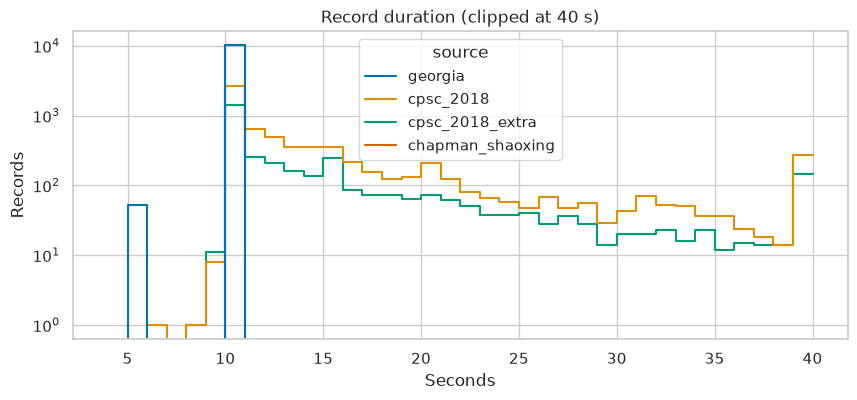

In [3]:
formats = headers.groupby("source").agg(
    records=("record", "size"),
    sampling_rates=("fs", lambda values: sorted(values.unique())),
    units=("units", lambda values: sorted(values.unique())),
    gain=("gain", lambda values: sorted(values.unique())),
    lead_orders=("lead_names", "nunique"),
).loc[SOURCES]
display(formats)
display(headers.groupby("source")["duration_s"].describe(percentiles=[0.05, 0.5, 0.95]).loc[SOURCES].round(1))
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(headers.assign(duration=headers["duration_s"].clip(upper=40)), x="duration", hue="source",
             hue_order=SOURCES, bins=np.arange(4, 41, 1), element="step", fill=False, ax=ax)
ax.set(title="Record duration (clipped at 40 s)", xlabel="Seconds", ylabel="Records", yscale="log")
plt.show()

**Finding: one format, different lengths.** All 30,921 records are 500 Hz, in mV, with a gain of 1000
per mV and the standard lead order, so they can be read the same way. Georgia and Chapman are ten
seconds (52 Georgia records are only five). CPSC 2018 and CPSC-Extra range from 6 to 144 seconds, with a
median of 12. A gain of 1000 per mV with 16-bit integers means the largest storable value is 32.767 mV;
that comes back in section 6.

## 2. Missing and implausible values

In [4]:
unusual_age = headers.loc[headers["age_years"].isna() | (headers["age_years"] < 0), "age"]
display(pd.crosstab(headers.loc[unusual_age.index, "source"], unusual_age).rename_axis(
    index="source", columns="age field"))
display(headers.groupby("source")["age_years"].agg(["min", "max"]).loc[SOURCES])
display(pd.crosstab(headers["source"], headers["sex"]).loc[SOURCES])
empty_dx = headers["dx_codes"].apply(len).eq(0)
print(f"Records with no diagnosis code: {empty_dx.sum()}")

age field,-1,NaN
source,,
cpsc_2018,4,5
cpsc_2018_extra,2,1
georgia,0,77


,min,max
source,,
georgia,14.0,89.0
cpsc_2018,-1.0,92.0
cpsc_2018_extra,-1.0,92.0
chapman_shaoxing,4.0,89.0


sex,Female,Male
source,,
georgia,4793,5551
cpsc_2018,3178,3699
cpsc_2018_extra,1610,1843
chapman_shaoxing,4514,5733


Records with no diagnosis code: 0


**Finding: metadata is nearly complete.** 83 records have `NaN` as age and 6 have `-1`, both meaning
unknown. Every record has a sex and at least one diagnosis code. Georgia and Chapman cap ages at 89, while
CPSC goes up to 92. No other implausible values exist in these few fields. The real data problems in these
sources are in duplicates and signals (sections 5-6).

## 3. Demographics

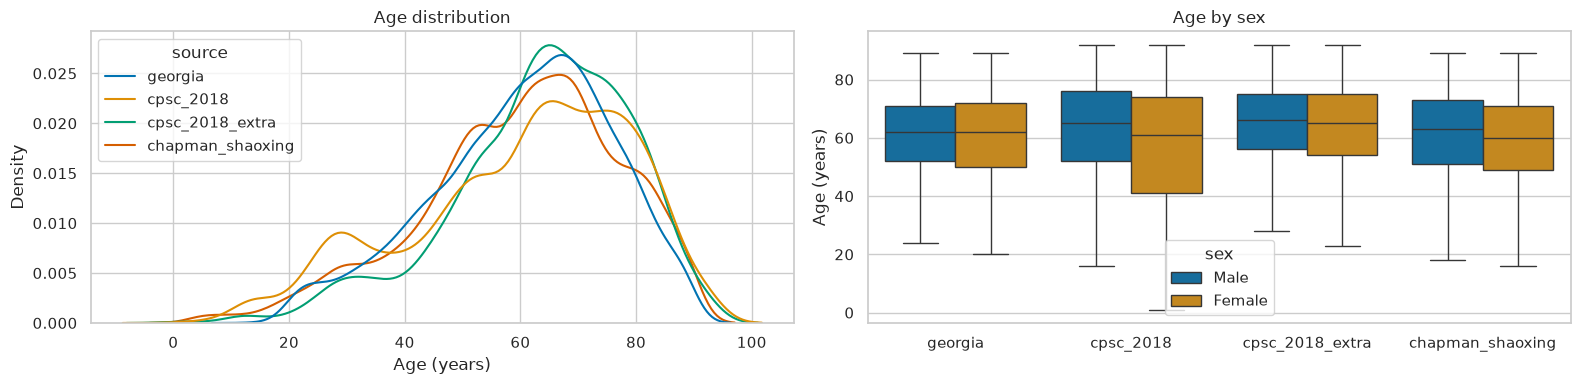

,median_age,male_share
source,,
georgia,62.0,0.54
cpsc_2018,64.0,0.54
cpsc_2018_extra,65.0,0.53
chapman_shaoxing,62.0,0.56


In [5]:
known = headers[headers["age_years"] >= 0]
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sns.kdeplot(known, x="age_years", hue="source", hue_order=SOURCES, common_norm=False, ax=axes[0])
axes[0].set(title="Age distribution", xlabel="Age (years)")
sns.boxplot(known, x="source", y="age_years", hue="sex", order=SOURCES, showfliers=False, ax=axes[1])
axes[1].set(title="Age by sex", xlabel="", ylabel="Age (years)")
plt.tight_layout()
plt.show()
demographics = known.groupby("source").agg(median_age=("age_years", "median"),
                                           male_share=("sex", lambda values: values.eq("Male").mean()))
display(demographics.loc[SOURCES].round(2))

**Finding.** All four are adult cardiology populations with median ages between 62 and 65 and a slight male
majority (53-56%), similar to PTB-XL. CPSC 2018 has the widest age spread, with more young adults than the
others.

## 4. Diagnoses

Diagnoses are SNOMED-CT codes, named with the Challenge mapping tables in
`third_party/ecg-fm-benchmarking`.

Distinct codes: 103; without a name in the mapping: ['251199005']


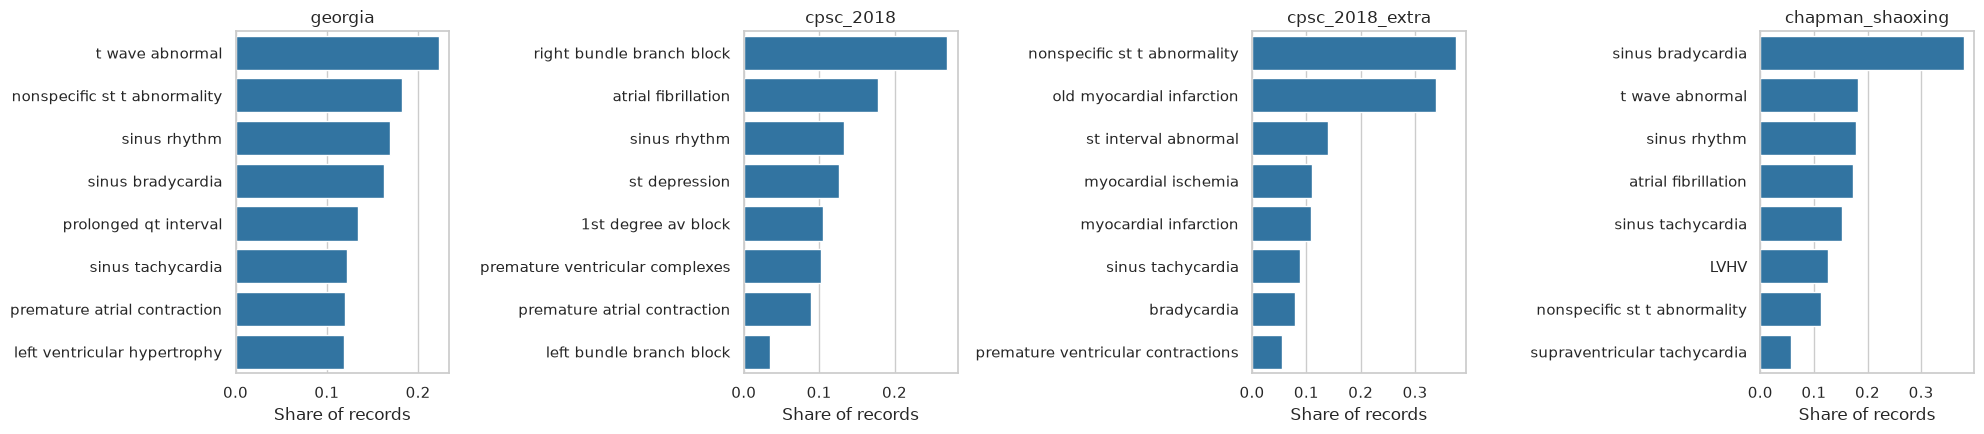

,codes_per_record,sinus_rhythm_only
source,,
georgia,2.331,0.169
cpsc_2018,1.070,0.133
cpsc_2018_extra,1.755,0.000
chapman_shaoxing,1.839,0.133


In [6]:
names = snomed_names()
codes = headers.explode("dx_codes")
unmapped = sorted(set(codes["dx_codes"]) - set(names))
print(f"Distinct codes: {codes['dx_codes'].nunique()}; without a name in the mapping: {unmapped}")
top = codes.groupby("source")["dx_codes"].value_counts().groupby(level=0).head(8)
top = top.rename("records").reset_index()
top["diagnosis"] = top["dx_codes"].map(names)
top["share"] = top["records"] / top["source"].map(headers["source"].value_counts())
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for axis, source in zip(axes, SOURCES, strict=True):
    rows = top[top["source"] == source]
    sns.barplot(rows, x="share", y="diagnosis", ax=axis, color="tab:blue")
    axis.set(title=source, xlabel="Share of records", ylabel="")
plt.tight_layout()
plt.show()
headers["sinus_rhythm_only"] = headers["dx_codes"].apply(lambda listed: listed == ["426783006"])
headers["codes"] = headers["dx_codes"].apply(len)
display(headers.groupby("source").agg(codes_per_record=("codes", "mean"),
                                      sinus_rhythm_only=("sinus_rhythm_only", "mean")).loc[SOURCES].round(3))

**Finding: four different case mixes, and plain normal ECGs are rare.**

- **CPSC 2018** was labeled with only nine classes, dominated by arrhythmias and conduction defects (right
  bundle branch block, atrial fibrillation, PVCs, first-degree AV block).
- **CPSC-Extra** holds the remaining CPSC recordings, mostly ischemic and infarct findings. None of them is
  sinus rhythm only.
- **Georgia** is broad: T-wave abnormalities, ST changes, sinus brady- and tachycardia.
- **Chapman/Shaoxing** is rhythm-oriented: sinus bradycardia is its most common label.

Only 0-17% of records per source are plain sinus rhythm. One code (251199005) has no name in the mapping.

## 5. Diagnoses, age and sex

Six findings that all four sources annotate (CPSC 2018 never labeled sinus brady- or tachycardia, so those
are left out for it). For each source we fit a logistic regression with age (per 10 years) and sex, and
we plot the age pattern of atrial fibrillation.

In [7]:
flags = condition_flags()
flags = flags[flags["source"].isin(SOURCES)].copy()
flags["age_band"] = age_band(flags["age"])
rows = []
for source in SOURCES:
    subset = flags[flags["source"] == source]
    usable = [condition for condition in CONDITIONS if subset[condition].sum() >= 30]
    rows.append(odds_ratios(subset, usable).assign(source=source))
ratios = pd.concat(rows)
table = ratios.pivot_table(index="outcome", columns=["predictor", "source"], values="odds_ratio")
display(table.reindex(CONDITIONS).round(2))

predictor                 age per 10 years                                               male                                  
source                    chapman_shaoxing cpsc_2018 cpsc_2018_extra georgia chapman_shaoxing cpsc_2018 cpsc_2018_extra georgia
outcome                                                                                                                        
atrial fibrillation                   2.25      1.66            1.73    1.86             1.02      0.99            1.01    1.59
right bundle branch block             1.65      1.09            1.64    1.26             1.56      1.79            1.71    1.98
left bundle branch block              1.74      1.46            1.64    1.59             1.53      0.74            1.69    0.76
1st degree AV block                   1.45      1.25            1.71    1.47             2.12      1.78            1.46    1.94
sinus bradycardia                     0.90       NaN            1.07    1.10             1.73       NaN            1.19    1.43
sinus tachycardia                     0.81       NaN            0.92    0.81             0.82       NaN            1.09    0.98

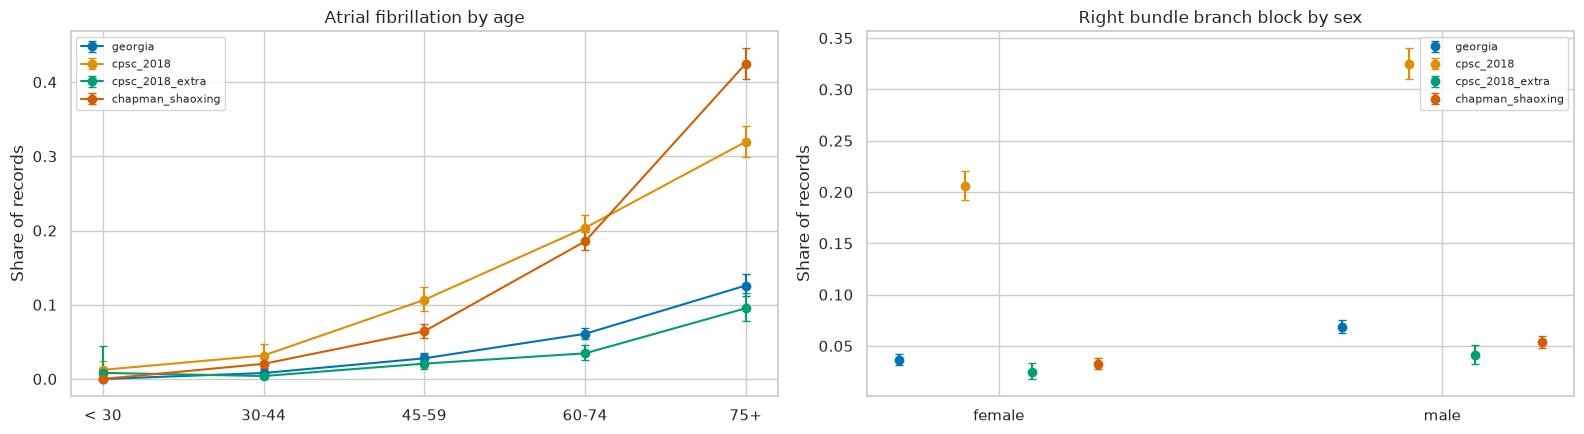

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
atrial = pd.concat([prevalence(flags[flags["source"] == source].dropna(subset=["age_band"]), "age_band",
                               ["atrial fibrillation"]).assign(outcome=source) for source in SOURCES])
plot_prevalence(atrial, "age_band", axes[0], "Atrial fibrillation by age")
branch = pd.concat([prevalence(flags[flags["source"] == source].assign(
    sex=np.where(flags.loc[flags["source"] == source, "male"], "male", "female")), "sex",
    ["right bundle branch block"]).assign(outcome=source) for source in SOURCES])
plot_prevalence(branch, "sex", axes[1], "Right bundle branch block by sex", connect=False)
plt.tight_layout()
plt.show()

**Finding: the same clinical patterns appear in every source.**

- **Atrial fibrillation** rises steeply with age everywhere: the odds increase 1.7-2.3x per decade, and
  in Chapman it reaches more than 40% of patients aged 75 and over.
- **Right bundle branch block** is more common in men in every source (odds ratio 1.6-2.0).
- **Left bundle branch block** behaves differently: it is *less* common in men in Georgia and CPSC 2018
  (odds ratio about 0.75) but more common in men in Chapman and CPSC-Extra (about 1.5-1.7). Unlike right
  bundle branch block, it has no consistent sex pattern.
- **First-degree AV block** rises with age and is more common in men. **Sinus tachycardia** becomes less
  common with age.

The absolute prevalences differ widely between sources (for example, atrial fibrillation is several times
more common in CPSC and Chapman than in Georgia), because each source was assembled with a different case
mix. Only the directions of the associations are comparable.

## 6. Duplicate recordings

The Challenge organizers assembled these sources from several releases, and CPSC-Extra comes from the
same hospitals as CPSC 2018. We hash every record's samples (at the 1 microvolt storage resolution) to find
exact duplicates.

In [9]:
headers["hash"] = signal_hashes(headers)
duplicated = headers[headers["hash"].duplicated(keep=False)]
groups = duplicated.groupby("hash").agg(sources=("source", lambda values: " + ".join(sorted(values))),
                                         diagnoses=("dx", "nunique"))
display(pd.Series({"records that have an exact copy": len(duplicated),
                   "duplicate groups": len(groups),
                   "groups whose copies carry different diagnoses": int((groups["diagnoses"] > 1).sum())})
        .to_frame("count"))
display(groups["sources"].value_counts().head(8).to_frame("groups"))

,count
records that have an exact copy,1508
duplicate groups,742
groups whose copies carry different diagnoses,344


,groups
sources,
cpsc_2018 + cpsc_2018_extra,319
cpsc_2018 + cpsc_2018,238
georgia + georgia,90
cpsc_2018_extra + cpsc_2018_extra,60
chapman_shaoxing + chapman_shaoxing,13
cpsc_2018 + cpsc_2018 + cpsc_2018_extra,8
cpsc_2018 + cpsc_2018_extra + cpsc_2018_extra,7
georgia + georgia + georgia,2


**Finding: 1,508 records (5%) are exact copies of another record, and many disagree on the diagnosis.**
Most duplicates pair a CPSC 2018 record with a CPSC-Extra record, or two records within CPSC 2018. In 344
of the 742 groups, the identical signal carries different diagnosis codes. The same ECG was annotated more
than once, and the annotations disagree. Any analysis of these labels must deduplicate first, and the
conflicting groups show how noisy the labels are.

## 7. Signal integrity

All 30,921 records through the same checks as PTB-XL and MIMIC (about 5 minutes, then cached).

source,georgia,cpsc_2018,cpsc_2018_extra,chapman_shaoxing
records,10344,6877,3453,10247
any_nan,6,0,0,0
fully_constant_lead,9,18,8,15
lead_flat_for_1s,12,59,30,17
lead_over_10mv,18,99,55,22
limb_identity_violated,1,62,29,0
heart_rate_not_estimated,0,0,2,0


,peak_abs_mv,einthoven_residual,avf_residual,avl_residual,avr_residual
source,,,,,
cpsc_2018,32.755,32.741,0.002,32.741,65.482
cpsc_2018_extra,32.767,32.757,0.002,32.756,65.518
georgia,32.767,32.968,22.704,21.830,32.767


,records
records reaching 32.6 mV or more,83
... of which violate a limb identity,80
limb violations without saturation,12


,records,all_leads_together,median_samples,median_leads
source,,,,
cpsc_2018,50,0.76,6.5,12.0
cpsc_2018_extra,29,0.97,3.0,12.0
georgia,4,0.00,9.5,1.0


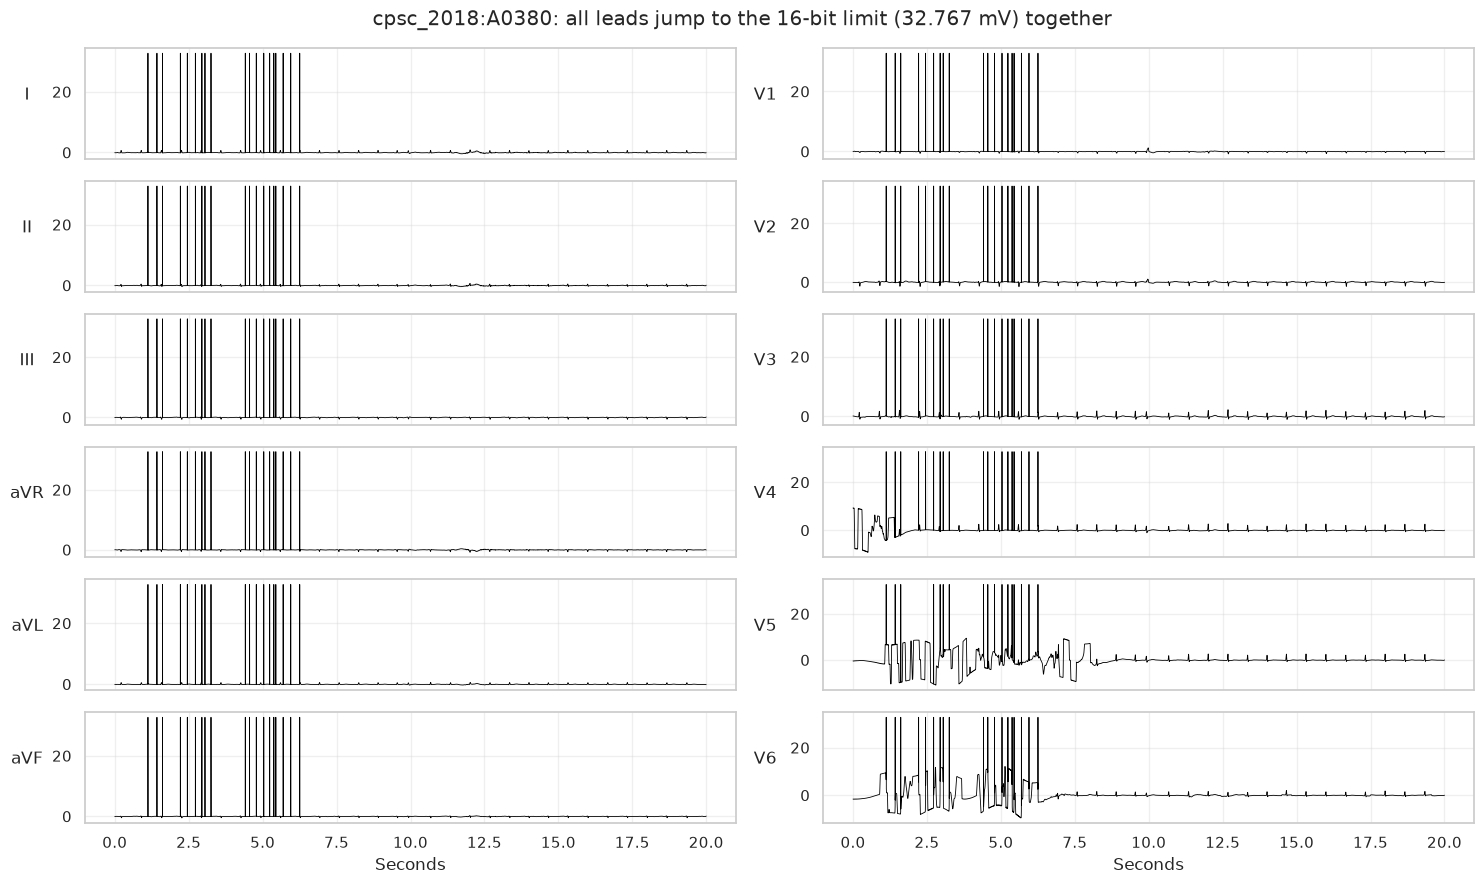

In [10]:
summary = challenge_summary(headers.drop(columns=["hash", "sinus_rhythm_only", "codes"]))
display(summary.groupby("source").apply(problem_counts).loc[SOURCES].T)
limb = summary[["einthoven_residual", "avf_residual", "avl_residual", "avr_residual"]].max(axis=1)
violated = summary[limb > 0.05]
display(violated.groupby("source")[["peak_abs_mv", "einthoven_residual", "avf_residual",
                                     "avl_residual", "avr_residual"]].median().round(3))
saturated = summary[summary["peak_abs_mv"] >= 32.6]
display(pd.Series({"records reaching 32.6 mV or more": len(saturated),
                   "... of which violate a limb identity": int((limb[saturated.index] > 0.05).sum()),
                   "limb violations without saturation":
                       int(((limb > 0.05) & (summary["peak_abs_mv"] < 32.6)).sum())})
        .to_frame("records"))
rows = []
for record_id in saturated.index:
    signal, _ = read_signal(f"{headers.loc[record_id, 'source']}:{headers.loc[record_id, 'path']}")
    rail = np.abs(signal) >= 32.6
    rows.append({"source": headers.loc[record_id, "source"],
                 "all leads at the rail together": bool((rail.any(axis=1) == rail.all(axis=1)).all()),
                 "samples at the rail": int(rail.any(axis=1).sum()),
                 "leads affected": int(rail.any(axis=0).sum())})
pattern = pd.DataFrame(rows)
display(pattern.groupby("source").agg(records=("source", "size"),
                                      all_leads_together=("all leads at the rail together", "mean"),
                                      median_samples=("samples at the rail", "median"),
                                      median_leads=("leads affected", "median")).round(2))
typical = saturated[(saturated["source"] == "cpsc_2018") & (saturated["avf_residual"] < 0.01)]
example = typical.index[0]
signal, fs = read_signal(f"cpsc_2018:{headers.loc[example, 'path']}")
plot_ecg(signal, fs, f"{example}: all leads jump to the 16-bit limit (32.767 mV) together", seconds=20)
plt.show()

**Finding: the large limb-lead violations are storage artifacts, not lead swaps.** 80 of the 92 violating
records (almost all of them CPSC) reach the 32.767 mV storage limit. The residual pattern (Einthoven about 32.7 mV, aVR
about 65.5 mV, aVF about 0) is exactly what you get when **all twelve leads are set to +32.767 mV at the same
instant**, as in the example: a handful of samples (median 3-6) where every lead jumps to the maximum
value. In 76% of affected CPSC 2018 records and 97% of CPSC-Extra records, every rail value is simultaneous
across all twelve leads. This is a storage or export artifact, not an amplifier saturating. The 4 Georgia records are genuine single-lead saturation, and Chapman has
none. The other problems are small: 50 records with a constant lead, 6 Georgia records with NaN samples,
and 12 minor limb inconsistencies.

## 8. Signal distributions compared with PTB-XL

,peak_abs_mv,std,baseline_fraction,high_frequency_fraction,powerline_50_fraction,heart_rate
source,,,,,,
ptbxl,1.905,0.152,0.020,0.007,7.000e-04,71.259
georgia,1.654,0.143,0.024,0.008,8.000e-04,75.282
cpsc_2018,2.083,0.149,0.006,0.005,5.000e-04,76.923
cpsc_2018_extra,2.060,0.143,0.006,0.005,5.000e-04,76.628
chapman_shaoxing,2.230,0.151,0.023,0.012,1.200e-03,73.529


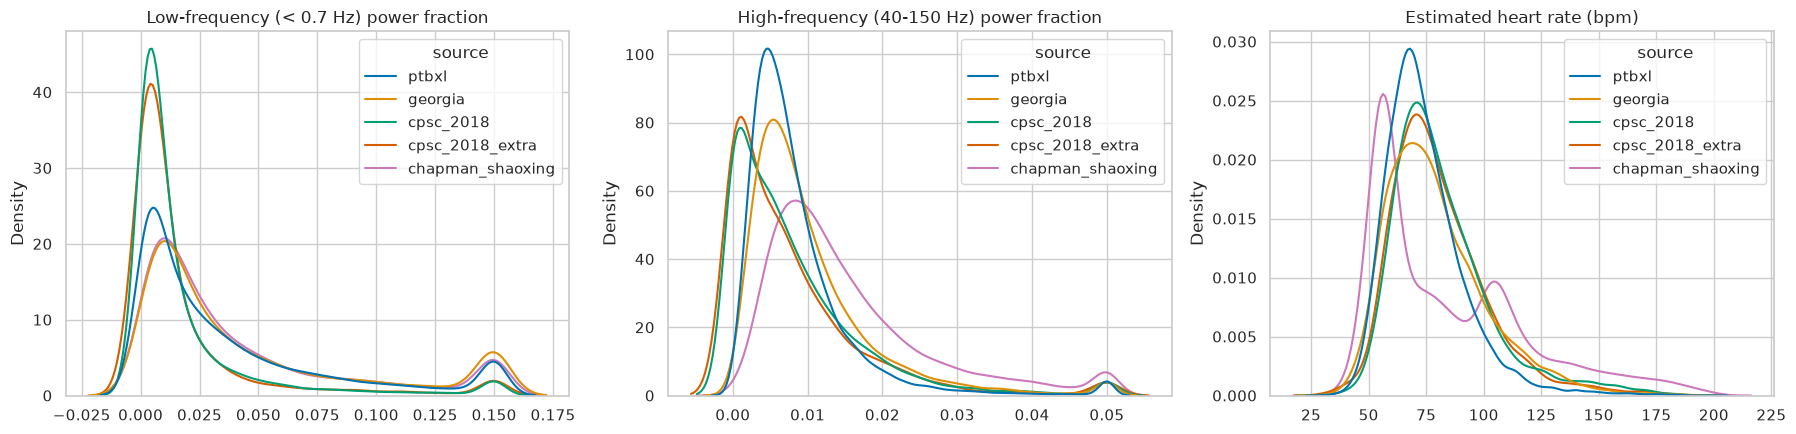

In [11]:
ptbxl = ptbxl_summary(load_metadata()).assign(source="ptbxl")
metrics = ["peak_abs_mv", "std", "baseline_fraction", "high_frequency_fraction",
           "powerline_50_fraction", "heart_rate"]
combined = pd.concat([ptbxl[["source", *metrics]], summary[["source", *metrics]]])
display(combined.groupby("source")[metrics].median().loc[["ptbxl", *SOURCES]].round(4))
combined["baseline_fraction"] = combined["baseline_fraction"].clip(upper=0.15)
combined["high_frequency_fraction"] = combined["high_frequency_fraction"].clip(upper=0.05)
combined["heart_rate"] = combined["heart_rate"].clip(30, 200)
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
titles = {"baseline_fraction": "Low-frequency (< 0.7 Hz) power fraction",
          "high_frequency_fraction": "High-frequency (40-150 Hz) power fraction",
          "heart_rate": "Estimated heart rate (bpm)"}
for axis, (column, title) in zip(axes, titles.items(), strict=True):
    sns.kdeplot(combined, x=column, hue="source", hue_order=["ptbxl", *SOURCES], common_norm=False, ax=axis)
    axis.set(title=title, xlabel="")
plt.tight_layout()
plt.show()

**Finding: three filtering regimes.** CPSC 2018 and CPSC-Extra have about 3x less low-frequency power and
less high-frequency power than PTB-XL. They were band-pass filtered before release, and they are nearly
indistinguishable from each other, as expected for recordings from the same hospitals. Chapman has the most
high-frequency content, about twice PTB-XL's. Georgia sits close to PTB-XL. Amplitudes and heart rates are
similar everywhere.

## 9. Conclusions about the datasets

- **Format.** One consistent format (500 Hz, mV, standard lead order). Georgia and Chapman are ten seconds;
  CPSC records are longer and variable (6-144 s).
- **Missing and wrong values.** Metadata is nearly complete (89 unknown ages). The real problems are 1,508
  exact duplicate recordings, 344 groups of which carry conflicting diagnoses, and rail-value artifacts in
  79 CPSC records.
- **Diagnoses.** Each source has its own case mix, and plain sinus rhythm is rare (0-17%). The associations
  with age and sex are nevertheless the same everywhere and match clinical knowledge: atrial fibrillation
  rises steeply with age, right bundle branch block is male-dominated, left bundle branch block is not.
- **Signals.** Clean apart from those artifacts. The sources differ in filtering: CPSC is heavily filtered,
  Chapman is noisy at high frequency, and Georgia resembles PTB-XL.

The next notebook describes CODE-15%, the largest labeled source.